In [102]:
!pip -q install numpy pandas scipy statsmodels matplotlib

## Imports

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

## Configuração Comum

In [104]:
sample_size = (30, 100)
b_0 = 1.0
b_1 = 2.0
replications = 1000

In [105]:
def generate_data(n, b_0, b_1, eps, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    x_ref = rng.uniform(0, 10, n)
    y_ref = b_0 + b_1 * x_ref + eps
    return x_ref, y_ref


def fit_mrls(x, y):
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    return {
        "beta0_hat": model.params[0],
        "beta1_hat": model.params[1],
        "beta0_se": model.bse[0],
        "beta1_se": model.bse[1],
        "beta0_ci_low": model.conf_int()[0, 0],
        "beta0_ci_high": model.conf_int()[0, 1],
        "beta1_ci_low": model.conf_int()[1, 0],
        "beta1_ci_high": model.conf_int()[1, 1],
        "r2": model.rsquared,
    }

## Modelo Clássico Normal

In [106]:
def _normal_errors(n, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    return rng.normal(0, 1, n)

def simulate_reference_scenario(sample_size, b_0, b_1, replications, seed=42):
    rng = np.random.default_rng(seed)
    results = []
    samples = []

    for _ in range(replications):
        x_ref_30, y_ref_30 = generate_data(
            sample_size[0], b_0, b_1, _normal_errors(sample_size[0], rng), rng
        )
        x_ref_100, y_ref_100 = generate_data(
            sample_size[1], b_0, b_1, _normal_errors(sample_size[1], rng), rng
        )
        samples.append((x_ref_30, y_ref_30, x_ref_100, y_ref_100))
        results.append(
            {
                "n_30": fit_mrls(x_ref_30, y_ref_30),
                "n_100": fit_mrls(x_ref_100, y_ref_100),
            }
        )

    return samples, results

def summarize_simulation(results, true_beta0, true_beta1, key):
    beta0 = np.array([item[key]["beta0_hat"] for item in results])
    beta1 = np.array([item[key]["beta1_hat"] for item in results])

    return pd.DataFrame(
        {
            "métrica": ["média", "viés", "variância", "EQM"],
            "beta0": [
                beta0.mean(),
                beta0.mean() - true_beta0,
                beta0.var(ddof=1),
                ((beta0 - true_beta0) ** 2).mean(),
            ],
            "beta1": [
                beta1.mean(),
                beta1.mean() - true_beta1,
                beta1.var(ddof=1),
                ((beta1 - true_beta1) ** 2).mean(),
            ],
        }
    )

In [107]:
samples, results = simulate_reference_scenario(sample_size, b_0, b_1, replications)

x_ref_30, y_ref_30, x_ref_100, y_ref_100 = samples[0]

resumo_30 = summarize_simulation(results, b_0, b_1, "n_30")
resumo_100 = summarize_simulation(results, b_0, b_1, "n_100")

### Análise Gráfica

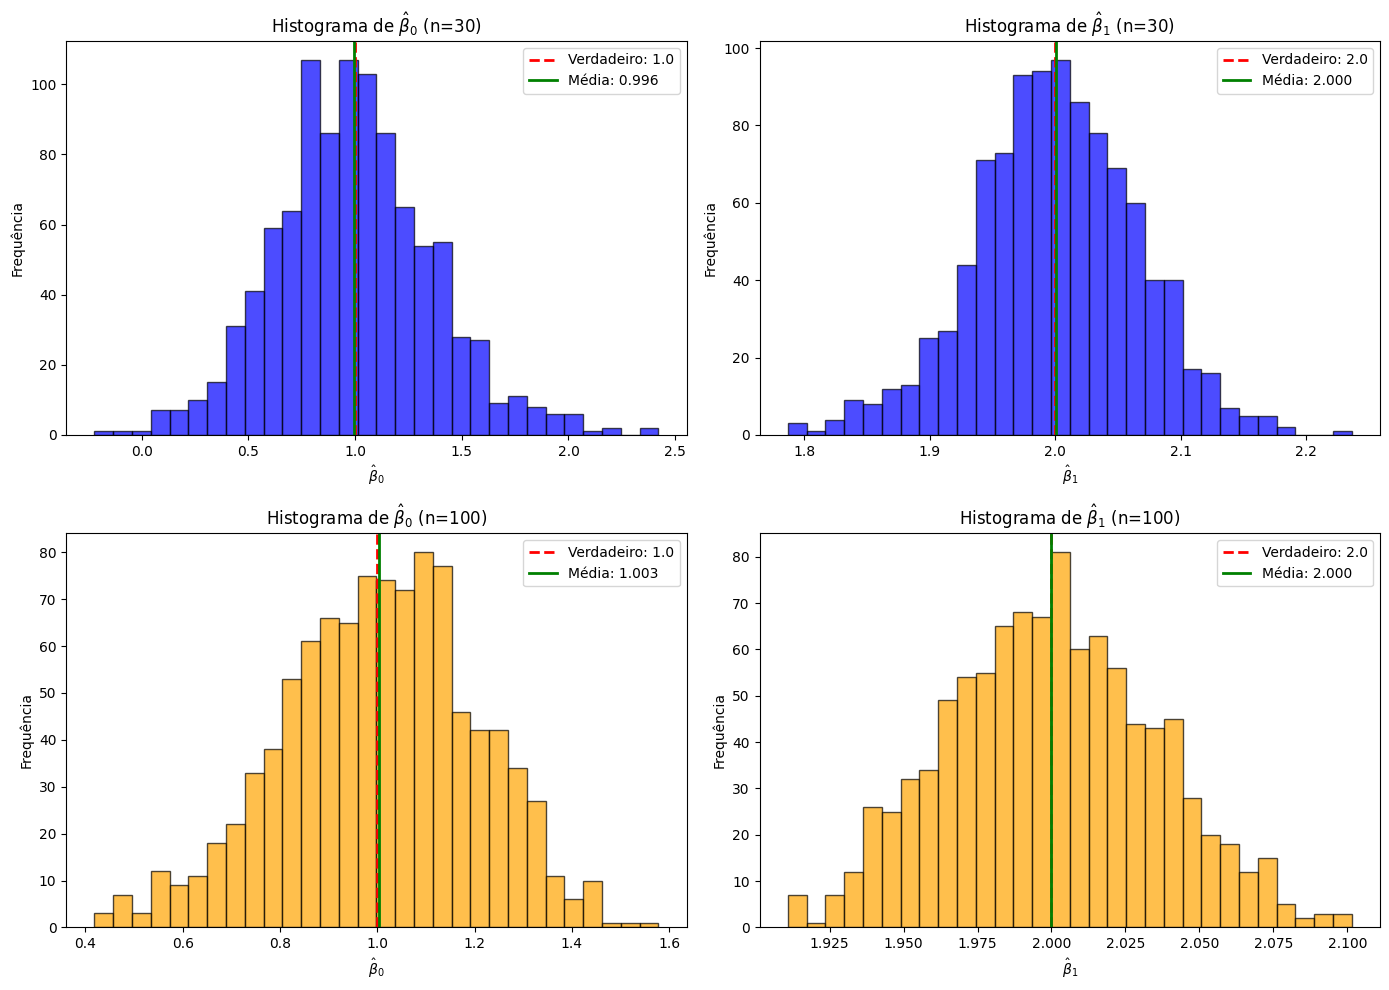

In [108]:
beta0_30 = np.array([item["n_30"]["beta0_hat"] for item in results])
beta1_30 = np.array([item["n_30"]["beta1_hat"] for item in results])
beta0_100 = np.array([item["n_100"]["beta0_hat"] for item in results])
beta1_100 = np.array([item["n_100"]["beta1_hat"] for item in results])

# Histogramas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(beta0_30, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].axvline(b_0, color='red', linestyle='--', linewidth=2, label=f'Verdadeiro: {b_0}')
axes[0, 0].axvline(beta0_30.mean(), color='green', linestyle='-', linewidth=2, label=f'Média: {beta0_30.mean():.3f}')
axes[0, 0].set_title('Histograma de $\\hat{\\beta}_0$ (n=30)')
axes[0, 0].set_xlabel('$\\hat{\\beta}_0$')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].legend()

axes[0, 1].hist(beta1_30, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0, 1].axvline(b_1, color='red', linestyle='--', linewidth=2, label=f'Verdadeiro: {b_1}')
axes[0, 1].axvline(beta1_30.mean(), color='green', linestyle='-', linewidth=2, label=f'Média: {beta1_30.mean():.3f}')
axes[0, 1].set_title('Histograma de $\\hat{\\beta}_1$ (n=30)')
axes[0, 1].set_xlabel('$\\hat{\\beta}_1$')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].legend()

axes[1, 0].hist(beta0_100, bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[1, 0].axvline(b_0, color='red', linestyle='--', linewidth=2, label=f'Verdadeiro: {b_0}')
axes[1, 0].axvline(beta0_100.mean(), color='green', linestyle='-', linewidth=2, label=f'Média: {beta0_100.mean():.3f}')
axes[1, 0].set_title('Histograma de $\\hat{\\beta}_0$ (n=100)')
axes[1, 0].set_xlabel('$\\hat{\\beta}_0$')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].legend()

axes[1, 1].hist(beta1_100, bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[1, 1].axvline(b_1, color='red', linestyle='--', linewidth=2, label=f'Verdadeiro: {b_1}')
axes[1, 1].axvline(beta1_100.mean(), color='green', linestyle='-', linewidth=2, label=f'Média: {beta1_100.mean():.3f}')
axes[1, 1].set_title('Histograma de $\\hat{\\beta}_1$ (n=100)')
axes[1, 1].set_xlabel('$\\hat{\\beta}_1$')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

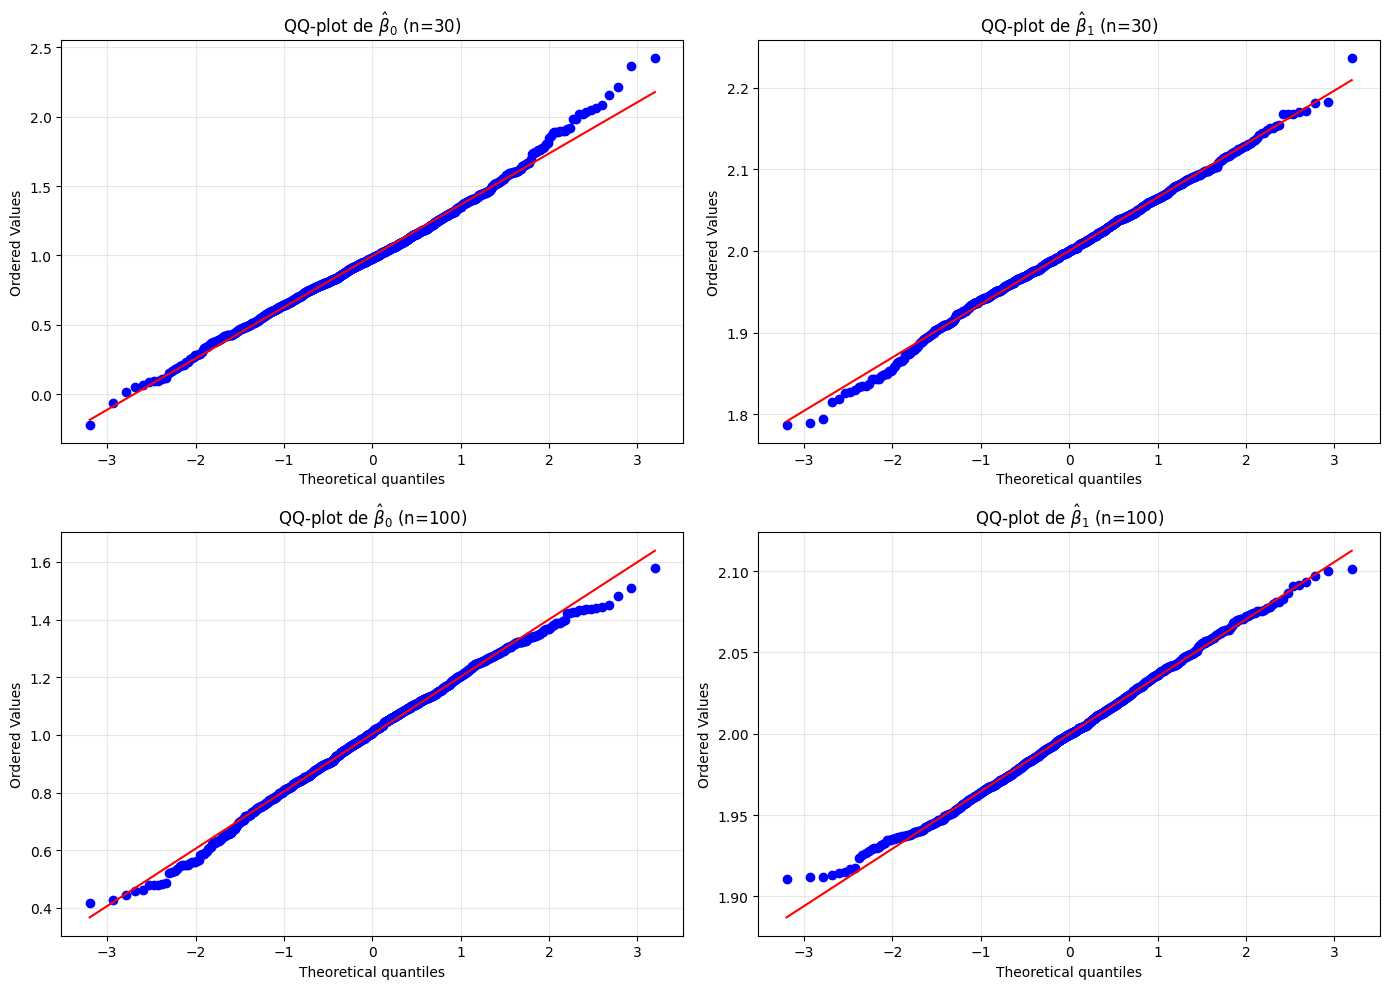

In [109]:
# QQ-plots para avaliar normalidade
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

stats.probplot(beta0_30, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('QQ-plot de $\\hat{\\beta}_0$ (n=30)')
axes[0, 0].grid(True, alpha=0.3)

stats.probplot(beta1_30, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('QQ-plot de $\\hat{\\beta}_1$ (n=30)')
axes[0, 1].grid(True, alpha=0.3)

stats.probplot(beta0_100, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ-plot de $\\hat{\\beta}_0$ (n=100)')
axes[1, 0].grid(True, alpha=0.3)

stats.probplot(beta1_100, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('QQ-plot de $\\hat{\\beta}_1$ (n=100)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\Arthur\AppData\Local\Temp\ipykernel_8572\3115878092.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp0 = axes[0].boxplot(data_beta0, labels=['n=30', 'n=100'], patch_artist=True)
C:\Users\Arthur\AppData\Local\Temp\ipykernel_8572\3115878092.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[1].boxplot(data_beta1, labels=['n=30', 'n=100'], patch_artist=True)


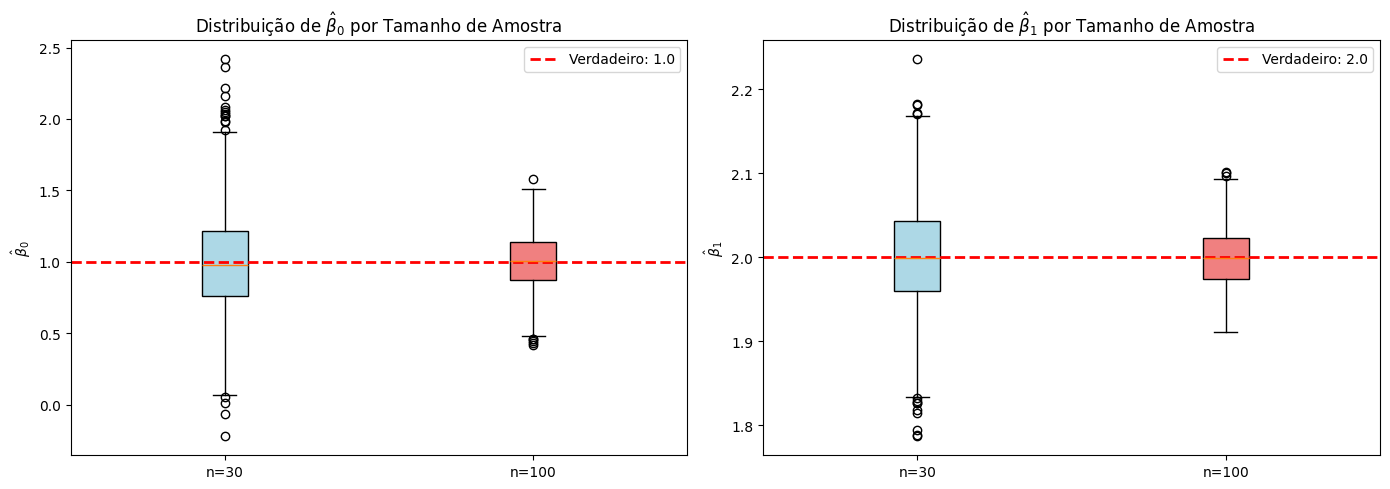

In [110]:
# Boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_beta0 = [beta0_30, beta0_100]
data_beta1 = [beta1_30, beta1_100]

bp0 = axes[0].boxplot(data_beta0, labels=['n=30', 'n=100'], patch_artist=True)
axes[0].axhline(b_0, color='red', linestyle='--', linewidth=2, label=f'Verdadeiro: {b_0}')
axes[0].set_ylabel('$\\hat{\\beta}_0$')
axes[0].set_title('Distribuição de $\\hat{\\beta}_0$ por Tamanho de Amostra')
axes[0].legend()
for patch, color in zip(bp0['boxes'], ['lightblue', 'lightcoral']):
    patch.set_facecolor(color)

bp1 = axes[1].boxplot(data_beta1, labels=['n=30', 'n=100'], patch_artist=True)
axes[1].axhline(b_1, color='red', linestyle='--', linewidth=2, label=f'Verdadeiro: {b_1}')
axes[1].set_ylabel('$\\hat{\\beta}_1$')
axes[1].set_title('Distribuição de $\\hat{\\beta}_1$ por Tamanho de Amostra')
axes[1].legend()
for patch, color in zip(bp1['boxes'], ['lightblue', 'lightcoral']):
    patch.set_facecolor(color)

plt.tight_layout()
plt.show()

## Erros com curtose elevada (caudas pesadas) 

In [115]:
def _t_distribution_errors(n, df=3, rng=None):
    """Gera erros com distribuição t de Student (caudas pesadas)."""
    rng = np.random.default_rng() if rng is None else rng
    return rng.standard_t(df, size=n)

def simulate_heavy_tails_scenario(sample_size, b_0, b_1, replications, df=3, seed=42):
    rng = np.random.default_rng(seed)
    results = []
    samples = []

    for _ in range(replications):
        x_ht_30, y_ht_30 = generate_data(
            sample_size[0], b_0, b_1, _t_distribution_errors(sample_size[0], df, rng), rng
        )
        x_ht_100, y_ht_100 = generate_data(
            sample_size[1], b_0, b_1, _t_distribution_errors(sample_size[1], df, rng), rng
        )
        samples.append((x_ht_30, y_ht_30, x_ht_100, y_ht_100))
        results.append(
            {
                "n_30": fit_mrls(x_ht_30, y_ht_30),
                "n_100": fit_mrls(x_ht_100, y_ht_100),
            }
        )

    return samples, results

samples_ht, results_ht = simulate_heavy_tails_scenario(sample_size, b_0, b_1, replications)

resumo_30_ht = summarize_simulation(results_ht, b_0, b_1, "n_30")
resumo_100_ht = summarize_simulation(results_ht, b_0, b_1, "n_100")

### Análise Gráfica

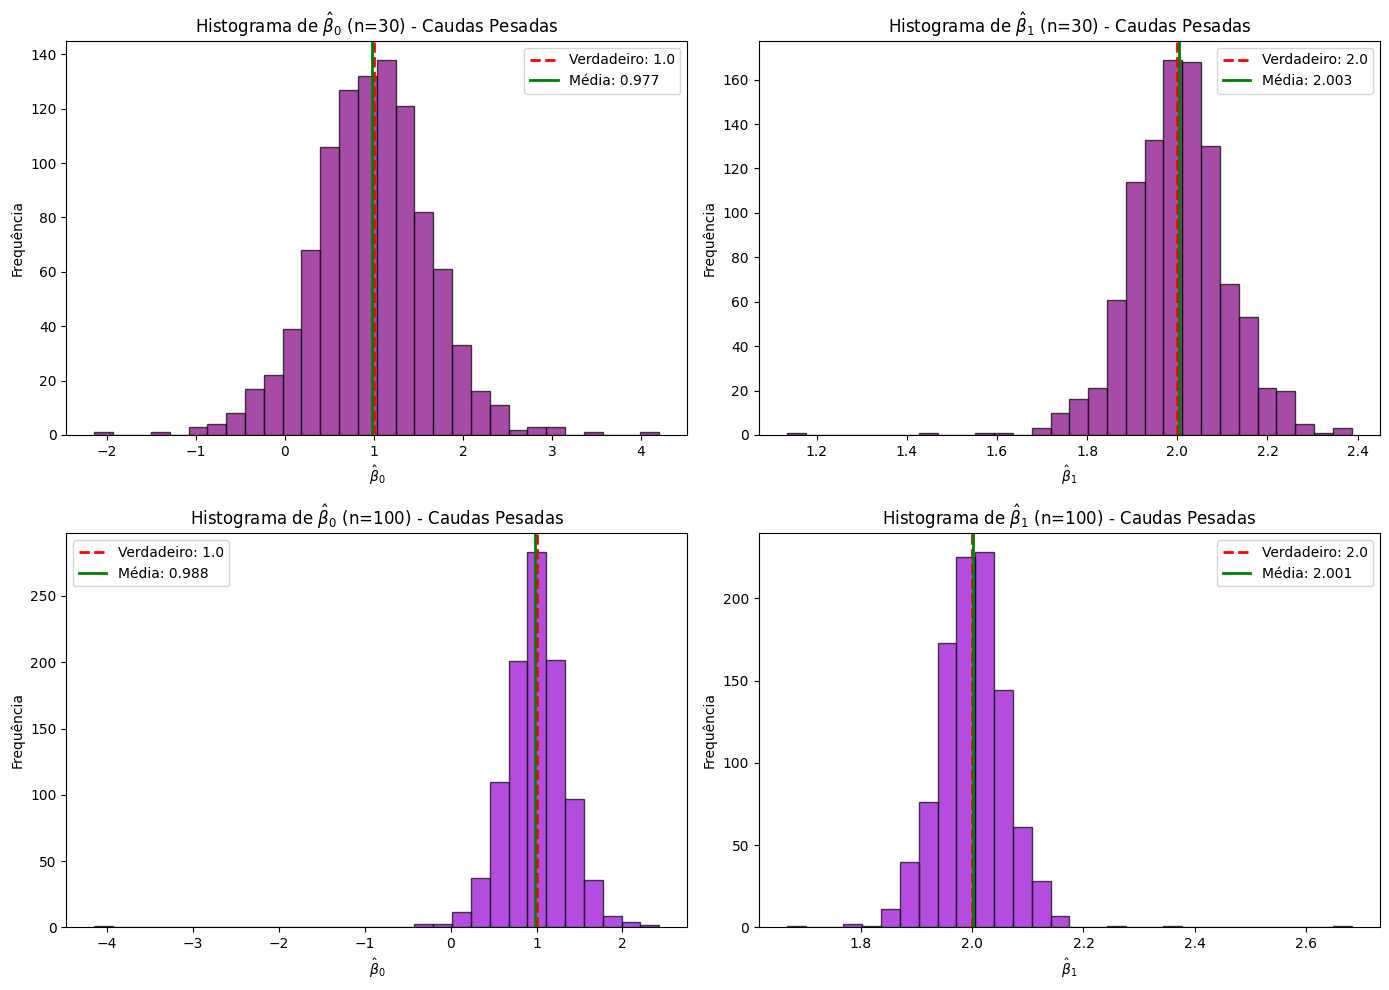

In [119]:
beta0_30_ht = np.array([item["n_30"]["beta0_hat"] for item in results_ht])
beta1_30_ht = np.array([item["n_30"]["beta1_hat"] for item in results_ht])
beta0_100_ht = np.array([item["n_100"]["beta0_hat"] for item in results_ht])
beta1_100_ht = np.array([item["n_100"]["beta1_hat"] for item in results_ht])

# Histogramas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(beta0_30_ht, bins=30, alpha=0.7, color='purple', edgecolor='black')
axes[0, 0].axvline(b_0, color='red', linestyle='--', linewidth=2, label=f'Verdadeiro: {b_0}')
axes[0, 0].axvline(beta0_30_ht.mean(), color='green', linestyle='-', linewidth=2, label=f'Média: {beta0_30_ht.mean():.3f}')
axes[0, 0].set_title('Histograma de $\\hat{\\beta}_0$ (n=30) - Caudas Pesadas')
axes[0, 0].set_xlabel('$\\hat{\\beta}_0$')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].legend()

axes[0, 1].hist(beta1_30_ht, bins=30, alpha=0.7, color='purple', edgecolor='black')
axes[0, 1].axvline(b_1, color='red', linestyle='--', linewidth=2, label=f'Verdadeiro: {b_1}')
axes[0, 1].axvline(beta1_30_ht.mean(), color='green', linestyle='-', linewidth=2, label=f'Média: {beta1_30_ht.mean():.3f}')
axes[0, 1].set_title('Histograma de $\\hat{\\beta}_1$ (n=30) - Caudas Pesadas')
axes[0, 1].set_xlabel('$\\hat{\\beta}_1$')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].legend()

axes[1, 0].hist(beta0_100_ht, bins=30, alpha=0.7, color='darkviolet', edgecolor='black')
axes[1, 0].axvline(b_0, color='red', linestyle='--', linewidth=2, label=f'Verdadeiro: {b_0}')
axes[1, 0].axvline(beta0_100_ht.mean(), color='green', linestyle='-', linewidth=2, label=f'Média: {beta0_100_ht.mean():.3f}')
axes[1, 0].set_title('Histograma de $\\hat{\\beta}_0$ (n=100) - Caudas Pesadas')
axes[1, 0].set_xlabel('$\\hat{\\beta}_0$')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].legend()

axes[1, 1].hist(beta1_100_ht, bins=30, alpha=0.7, color='darkviolet', edgecolor='black')
axes[1, 1].axvline(b_1, color='red', linestyle='--', linewidth=2, label=f'Verdadeiro: {b_1}')
axes[1, 1].axvline(beta1_100_ht.mean(), color='green', linestyle='-', linewidth=2, label=f'Média: {beta1_100_ht.mean():.3f}')
axes[1, 1].set_title('Histograma de $\\hat{\\beta}_1$ (n=100) - Caudas Pesadas')
axes[1, 1].set_xlabel('$\\hat{\\beta}_1$')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

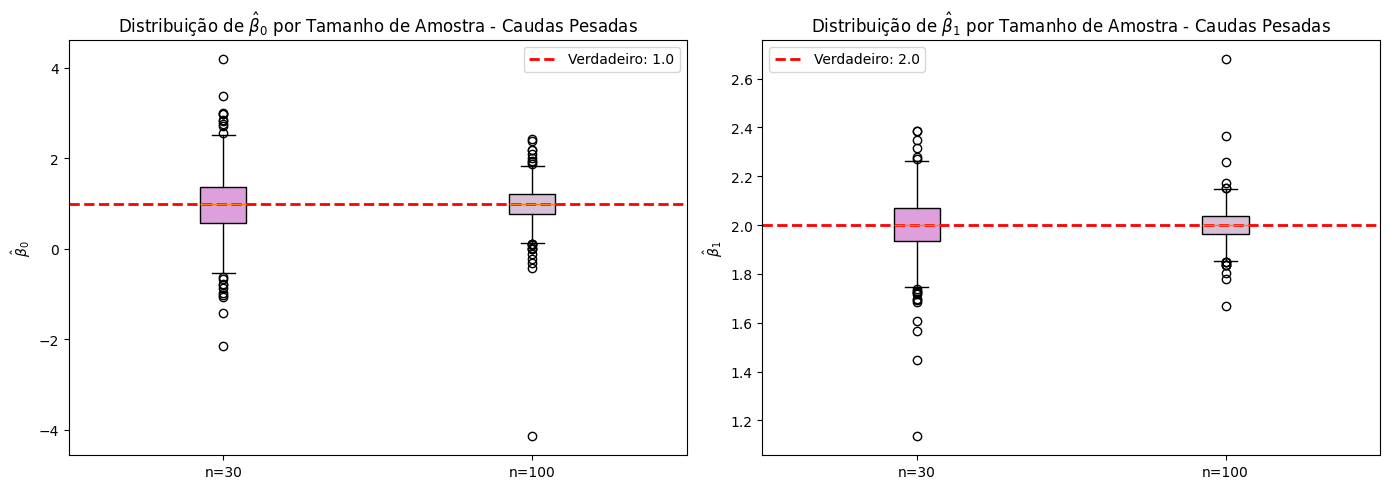

In [116]:
# Boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_beta0_ht = [beta0_30_ht, beta0_100_ht]
data_beta1_ht = [beta1_30_ht, beta1_100_ht]

bp0_ht = axes[0].boxplot(data_beta0_ht, tick_labels=['n=30', 'n=100'], patch_artist=True)
axes[0].axhline(b_0, color='red', linestyle='--', linewidth=2, label=f'Verdadeiro: {b_0}')
axes[0].set_ylabel('$\\hat{\\beta}_0$')
axes[0].set_title('Distribuição de $\\hat{\\beta}_0$ por Tamanho de Amostra - Caudas Pesadas')
axes[0].legend()
for patch, color in zip(bp0_ht['boxes'], ['plum', 'thistle']):
    patch.set_facecolor(color)

bp1_ht = axes[1].boxplot(data_beta1_ht, tick_labels=['n=30', 'n=100'], patch_artist=True)
axes[1].axhline(b_1, color='red', linestyle='--', linewidth=2, label=f'Verdadeiro: {b_1}')
axes[1].set_ylabel('$\\hat{\\beta}_1$')
axes[1].set_title('Distribuição de $\\hat{\\beta}_1$ por Tamanho de Amostra - Caudas Pesadas')
axes[1].legend()
for patch, color in zip(bp1_ht['boxes'], ['plum', 'thistle']):
    patch.set_facecolor(color)

plt.tight_layout()
plt.show()

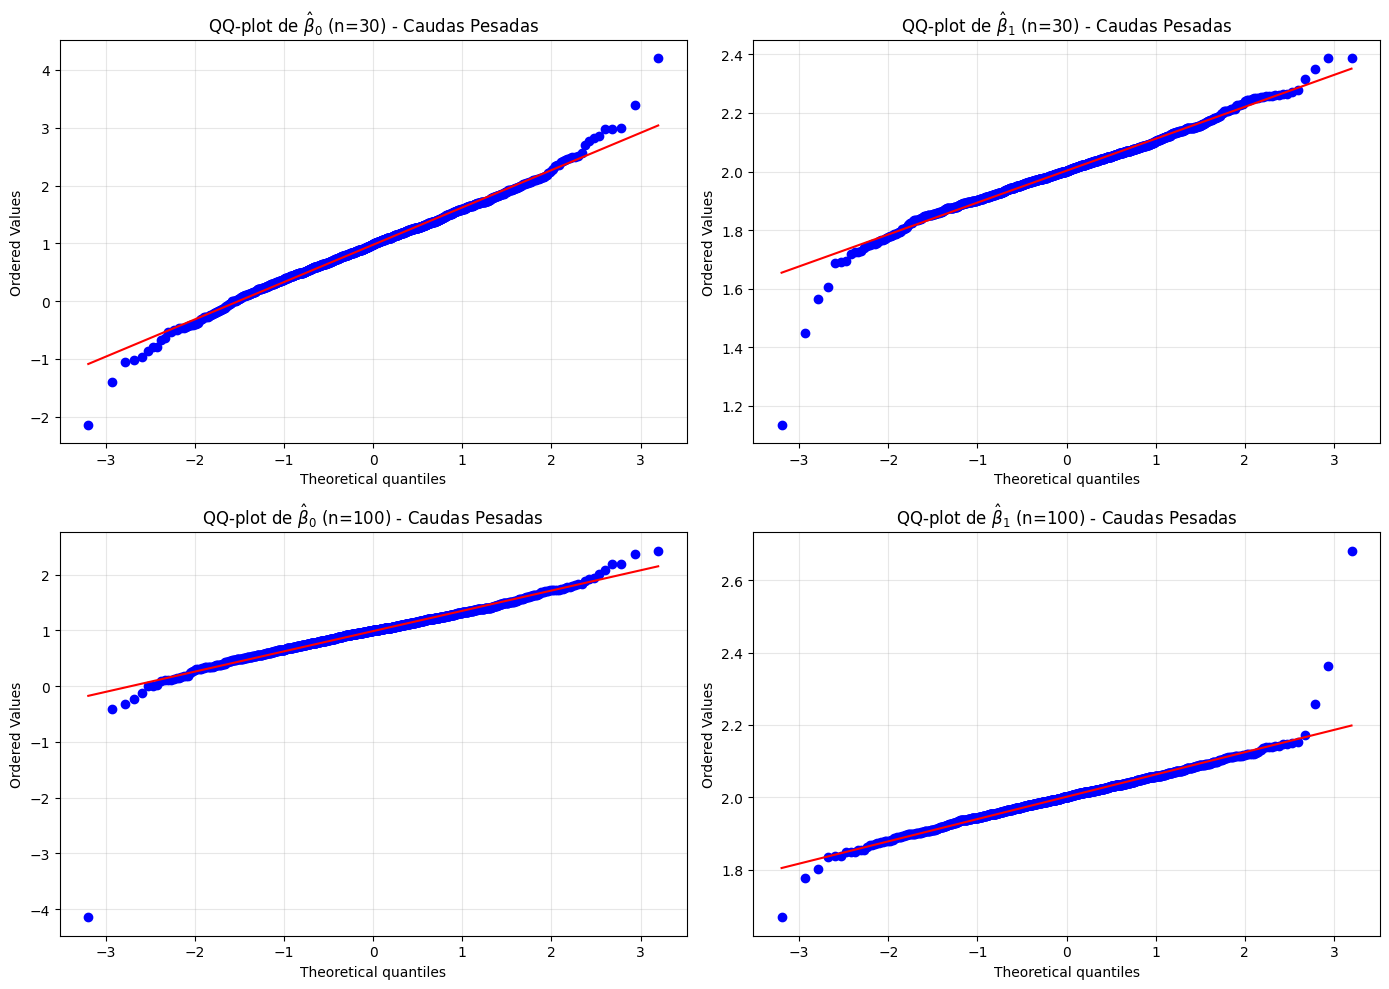

In [117]:
# QQ-plots para avaliar normalidade
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

stats.probplot(beta0_30_ht, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('QQ-plot de $\\hat{\\beta}_0$ (n=30) - Caudas Pesadas')
axes[0, 0].grid(True, alpha=0.3)

stats.probplot(beta1_30_ht, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('QQ-plot de $\\hat{\\beta}_1$ (n=30) - Caudas Pesadas')
axes[0, 1].grid(True, alpha=0.3)

stats.probplot(beta0_100_ht, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ-plot de $\\hat{\\beta}_0$ (n=100) - Caudas Pesadas')
axes[1, 0].grid(True, alpha=0.3)

stats.probplot(beta1_100_ht, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('QQ-plot de $\\hat{\\beta}_1$ (n=100) - Caudas Pesadas')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()